
# Aula de Machine Learning — Classificação Supervisionada

## Modelos abordados

- Regressão Logística
- Árvore de Decisão
- SVM (Support Vector Machine)
- Naive Bayes

---

## Objetivos da Aula

Ao final da aula o aluno deverá ser capaz de:

- Entender modelos supervisionados de classificação
- Implementar modelos em Python




# Contexto do Problema

Imagine que somos um banco.

Nosso objetivo é prever se um cliente irá:

- Aprovar crédito → 1
- Não aprovar crédito → 0

Com base nas variáveis:

- renda
- score de crédito
- idade
- número de atrasos


In [2]:

# ======================================
# 1. IMPORTANDO BIBLIOTECAS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualização da árvore
from sklearn.tree import plot_tree

# Normalização
from sklearn.preprocessing import StandardScaler


In [4]:

# ======================================
# 2. CRIANDO BASE DE DADOS
# ======================================

np.random.seed(42)

n = 200

renda = np.random.randint(2000, 15000, n)
score = np.random.randint(300, 900, n)
idade = np.random.randint(18, 70, n)
atrasos = np.random.randint(0, 10, n)

# Regra artificial

aprovado = (
    (renda > 5000) &
    (score > 600) &
    (atrasos < 3)
).astype(int)

dados = pd.DataFrame({
    'renda': renda,
    'score': score,
    'idade': idade,
    'atrasos': atrasos,
    'aprovado': aprovado
})

dados.head()



,renda,score,idade,atrasos,aprovado
0,9270,558,26,9,0
1,2860,658,29,1,0
2,7390,755,18,4,0
3,7191,710,18,4,0
4,13964,617,64,5,0
5,13284,524,51,2,0
6,7734,533,49,7,0
7,8265,673,65,0,1
8,2466,771,42,5,0
9,6426,532,57,3,0


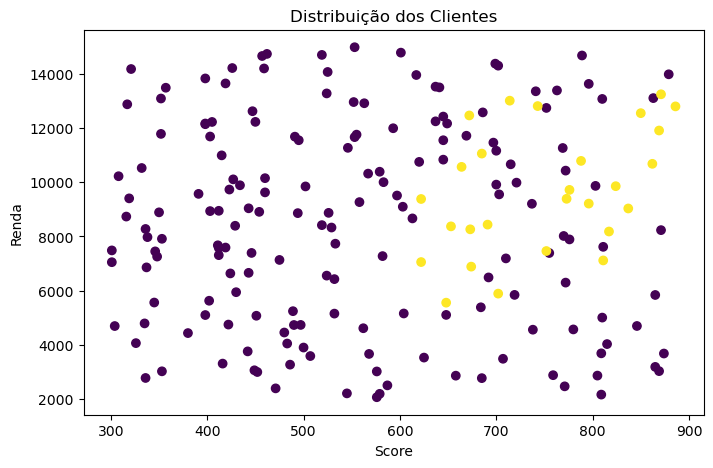

In [5]:

# ======================================
# 3. VISUALIZAÇÃO DOS DADOS
# ======================================

plt.figure(figsize=(8,5))

plt.scatter(
    dados['score'],
    dados['renda'],
    c=dados['aprovado']
)

plt.xlabel('Score')
plt.ylabel('Renda')
plt.title('Distribuição dos Clientes')

plt.show()


In [6]:

# ======================================
# 4. DEFININDO X E y
# ======================================

X = dados[['renda', 'score', 'idade', 'atrasos']]
y = dados['aprovado']


In [7]:

# ======================================
# 5. DIVISÃO TREINO E TESTE
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)


Treino: (160, 4)
Teste: (40, 4)



# Importante — Normalização

## NÃO precisam:
- Árvores
- Naive Bayes

## Precisam:
- Regressão Logística
- SVM


In [8]:

# ======================================
# 6. NORMALIZAÇÃO
# ======================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Modelo 1 — Regressão Logística

A regressão logística estima probabilidades.

Ela utiliza a função sigmoide.


In [9]:

# ======================================
# REGRESSÃO LOGÍSTICA
# ======================================

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)

acc_log = accuracy_score(y_test, pred_log)

print('Acurácia:', acc_log)


Acurácia: 0.975


In [10]:

# MATRIZ DE CONFUSÃO

cm_log = confusion_matrix(y_test, pred_log)

print(cm_log)


[[34  0]
 [ 1  5]]



# Explicação Didática

Explique:

- Verdadeiro Positivo
- Verdadeiro Negativo
- Falso Positivo
- Falso Negativo



# Modelo 2 — Árvore de Decisão

A árvore cria regras hierárquicas.


In [12]:

# ======================================
# ÁRVORE DE DECISÃO
# ======================================

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(y_test, pred_tree)

print('Acurácia:', acc_tree)


Acurácia: 1.0


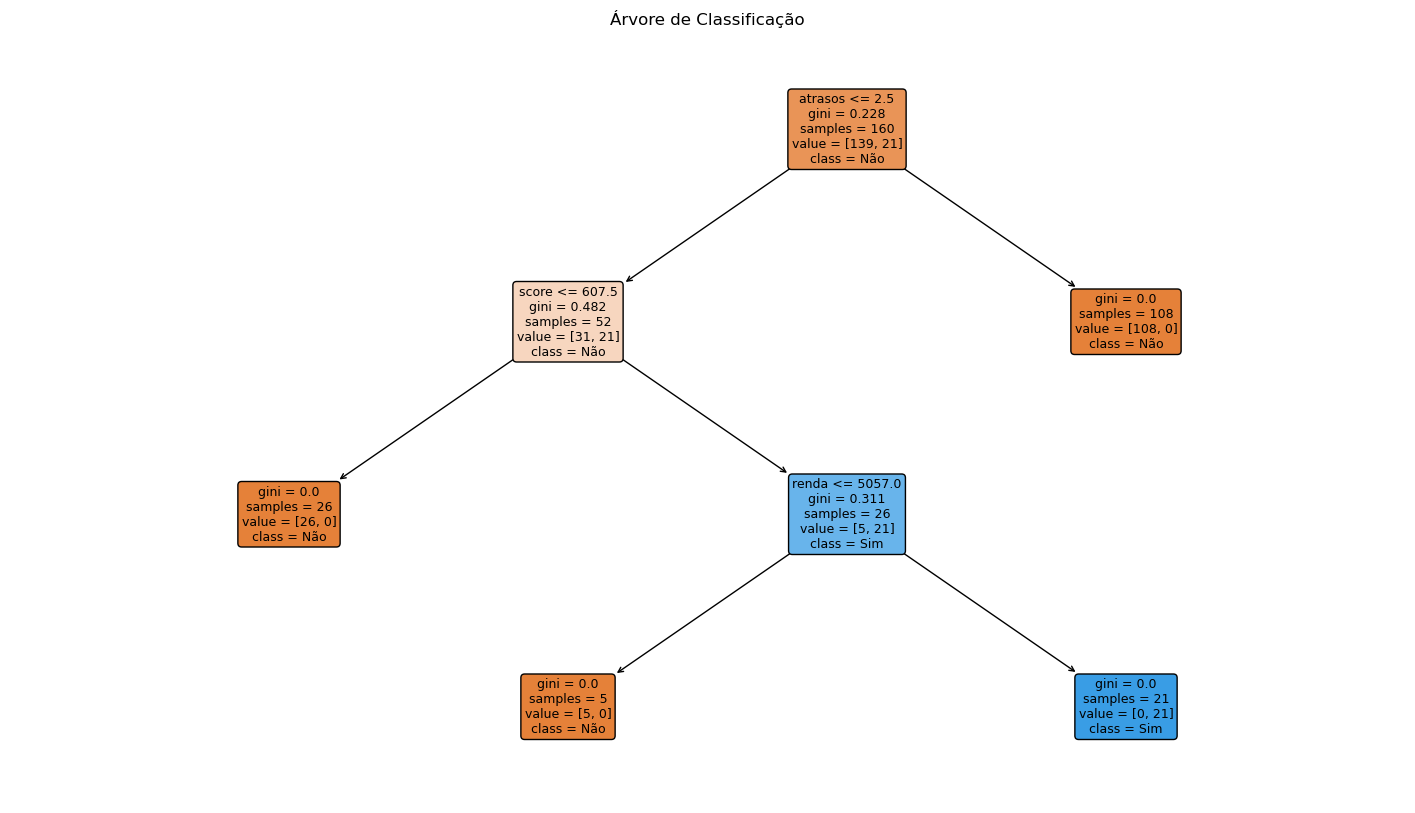

In [13]:

# ======================================
# VISUALIZANDO A ÁRVORE
# ======================================

plt.figure(figsize=(18,10))

plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=['Não', 'Sim'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title('Árvore de Classificação')
plt.show()



# Modelo 3 — SVM

O SVM tenta encontrar a melhor fronteira de separação.


In [14]:

# ======================================
# SVM
# ======================================

svm_model = SVC(
    kernel='rbf'
)

svm_model.fit(X_train_scaled, y_train)

pred_svm = svm_model.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, pred_svm)

print('Acurácia:', acc_svm)


Acurácia: 1.0



# Modelo 4 — Naive Bayes

Naive Bayes utiliza probabilidade condicional.

Ele assume independência entre variáveis.


In [15]:

# ======================================
# NAIVE BAYES
# ======================================

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, pred_nb)

print('Acurácia:', acc_nb)


Acurácia: 1.0



# Comparação Final dos Modelos


In [16]:

# ======================================
# COMPARAÇÃO DOS MODELOS
# ======================================

resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore', 'SVM', 'Naive Bayes'],
    'Acurácia': [acc_log, acc_tree, acc_svm, acc_nb]
})

resultados


,Modelo,Acurácia
0,Regressão Logística,0.975
1,Árvore,1.000
2,SVM,1.000
3,Naive Bayes,1.000


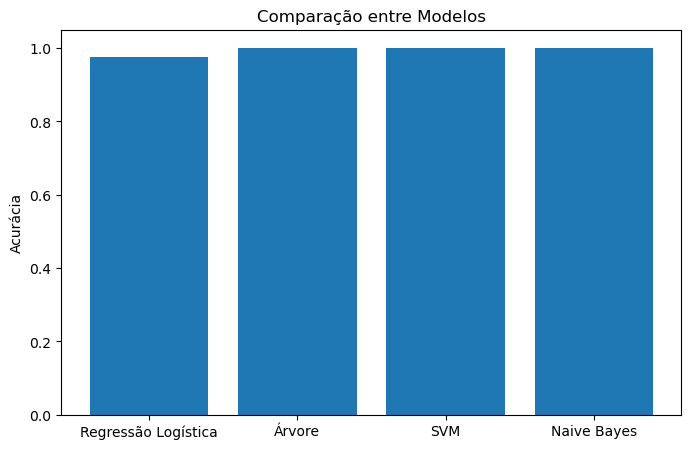

In [17]:

# ======================================
# VISUALIZAÇÃO FINAL
# ======================================

plt.figure(figsize=(8,5))

plt.bar(resultados['Modelo'], resultados['Acurácia'])

plt.ylabel('Acurácia')
plt.title('Comparação entre Modelos')

plt.show()



# Classification Report

Vamos analisar:

- precision
- recall
- f1-score


In [18]:

# ======================================
# CLASSIFICATION REPORT
# ======================================

print(classification_report(y_test, pred_log))


              precision    recall  f1-score   support

           0       0.97      1.00      0.99        34
           1       1.00      0.83      0.91         6

    accuracy                           0.97        40
   macro avg       0.99      0.92      0.95        40
weighted avg       0.98      0.97      0.97        40




# Exercícios para os alunos

1. Alterar profundidade da árvore
2. Alterar kernel do SVM
3. Inserir novas variáveis
4. Comparar métricas
5. Testar overfitting
6. Alterar threshold



# Resumo Final

| Modelo | Ideia Principal |
|---|---|
| Regressão Logística | Probabilidade |
| Árvore | Regras hierárquicas |
| SVM | Melhor fronteira |
| Naive Bayes | Probabilidades condicionais |
